# OGGM-VAS glacier reconstruction (CRU) + CMIP5/CMIP6 projections

**Workflow**
1. Reconstruct glacier evolution `MODEL_START_YEAR`-`RECON_END_YEAR` with VAS, forced by CRU (RGI 6.0).
2. For every entry in `EXPERIMENTS` (CMIP5 or CMIP6, GCM x scenario) bias-correct the GCM
   against CRU and run VAS from `RECON_END_YEAR` to `FUTURE_END_YEAR`.
3. Aggregate to regional volume / area / length / sea-level equivalent, plot and save CSVs.

**CMIP files can be given as**
* a direct link (`"https://.../tas_mon_CCSM4_rcp85_r1i1p1_g025.nc"`) - downloaded once into `CMIP_DATA_DIR/downloads` and reused
* an OPeNDAP link (contains `/dodsC/`) - read remotely, nothing is stored
* a local file, a wildcard (`"~/CMIP_data/tas_Amon_*_historical_*.nc"`) or a list of files (CMIP6 is often split in time chunks)

Everything is re-runnable: finished steps are detected on disk and skipped.

In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================
import hashlib
import inspect
import os
import re
import time
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence, Tuple, Union
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import requests
import matplotlib.pyplot as plt

import oggm.cfg as cfg
from oggm import workflow
from oggm.core import gis, climate
from oggm.shop import gcm_climate

import oggm_vas as vascaling


In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================
# ------------------------------------------------------------
# Region (RGI 6.0): number -> (display name, NSIDC file name part)
# ------------------------------------------------------------
RGI_REGIONS = {
    1: ("Alaska", "Alaska"),
    2: ("Western Canada and USA", "WesternCanadaAndUSA"),
    3: ("Arctic Canada North", "ArcticCanadaNorth"),
    4: ("Arctic Canada South", "ArcticCanadaSouth"),
    5: ("Greenland Periphery", "GreenlandPeriphery"),
    6: ("Iceland", "Iceland"),
    7: ("Svalbard", "Svalbard"),
    8: ("Scandinavia", "Scandinavia"),
    9: ("Russian Arctic", "RussianArctic"),
    10: ("North Asia", "NorthAsia"),
    11: ("Central Europe", "CentralEurope"),
    12: ("Caucasus and Middle East", "CaucasusMiddleEast"),
    13: ("Central Asia", "CentralAsia"),
    14: ("South Asia West", "SouthAsiaWest"),
    15: ("South Asia East", "SouthAsiaEast"),
    16: ("Low Latitudes", "LowLatitudes"),
    17: ("Southern Andes", "SouthernAndes"),
    18: ("New Zealand", "NewZealand"),
    19: ("Antarctic and Subantarctic", "AntarcticSubantarctic"),
}

RGI_VERSION = "60"
RGI_REGION = 8
REGION_NAME = RGI_REGIONS[RGI_REGION][0]

# ------------------------------------------------------------
# Reconstruction (CRU) and projection periods
# ------------------------------------------------------------
HISTORICAL_CLIMATE = "CRU"
MODEL_START_YEAR = 1901
RECON_END_YEAR = 2019          # end of the CRU reconstruction = start of the projections
FUTURE_END_YEAR = 2100
RUN_FUTURE = True

# ------------------------------------------------------------
# GCM bias correction against CRU
# ------------------------------------------------------------
BIAS_CORRECTION_PERIOD = ("1961", "1990")
APPLY_BIAS_CORRECTION = True
SCALE_STDDEV = True

# ------------------------------------------------------------
# Folders
# ------------------------------------------------------------
WORKDIR = Path(f"~/OGGM_VAS/RGI60_{RGI_REGION:02d}_{REGION_NAME.replace(' ', '')}").expanduser()
CMIP_DATA_DIR = Path("~/CMIP_data").expanduser()      # local CMIP files + download cache
RGI_CACHE_DIR = Path.home() / "OGGM" / "rgi60"

# ------------------------------------------------------------
# VAS calibration / run control
# ------------------------------------------------------------
FORCE_TSTAR = None             # set both to force t* and bias for all glaciers
FORCE_BIAS = None
RECOMPUTE_BASE = False         # True: redo masks / CRU climate / calibration / CRU run even if files exist
OVERWRITE_CMIP = False         # True: redo GCM bias correction even if gcm_data exists
REUSE_PROJECTIONS = True       # True: reuse finished projection CSVs instead of re-running
MAX_GLACIERS = None            # e.g. 20 for a quick test run

# ------------------------------------------------------------
# Physical constants
# ------------------------------------------------------------
RHO_ICE = 900.0
RHO_WATER = 1000.0
OCEAN_AREA_KM2 = 3.625e8

HIST_SUFFIX = f"_hist{MODEL_START_YEAR}_{RECON_END_YEAR}"
FUTURE_START_YEAR = RECON_END_YEAR

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------
if RGI_VERSION not in ("6", "60"):
    raise NotImplementedError("This notebook is written for RGI 6.0.")
if RGI_REGION not in RGI_REGIONS:
    raise ValueError("RGI_REGION must be between 1 and 19.")
if RECON_END_YEAR <= MODEL_START_YEAR:
    raise ValueError("RECON_END_YEAR must be after MODEL_START_YEAR.")
if FUTURE_END_YEAR <= RECON_END_YEAR:
    raise ValueError("FUTURE_END_YEAR must be after RECON_END_YEAR.")

WORKDIR.mkdir(parents=True, exist_ok=True)
CMIP_DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Region    :", f"RGI60-{RGI_REGION:02d} {REGION_NAME}")
print("Work dir  :", WORKDIR)
print("CMIP dir  :", CMIP_DATA_DIR)


Region    : RGI60-08 Scandinavia
Work dir  : /home/JasperE/OGGM_VAS/RGI60_08_Scandinavia
CMIP dir  : /home/JasperE/CMIP_data


In [3]:
# ============================================================
# 3. HELPERS: DOWNLOADS AND CMIP SOURCE RESOLUTION
# ============================================================
class DownloadError(RuntimeError):
    """Download problem that retrying will not fix (404, login page, ...)."""


def is_url(value):
    return str(value).strip().lower().startswith(("http://", "https://"))


def download_file(url, target, timeout=60, retries=3, chunk_size=1 << 20):
    """Stream `url` to `target` (via a .part file, so no half-written files)."""
    target = Path(target)
    target.parent.mkdir(parents=True, exist_ok=True)
    part = target.with_name(target.name + ".part")

    print(f"Downloading {url}")
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            with requests.get(url, stream=True, timeout=timeout) as response:
                if 400 <= response.status_code < 500:
                    raise DownloadError(
                        f"HTTP {response.status_code} for {url}. "
                        "If the server needs a login (ESGF, NASA Earthdata), "
                        "download the file in your browser and use the local path."
                    )
                response.raise_for_status()

                if "text/html" in response.headers.get("Content-Type", "").lower():
                    raise DownloadError(
                        f"{url} returned a web page instead of a file "
                        "(login or redirect page?). Download it manually "
                        "and use the local path."
                    )

                expected = response.headers.get("Content-Length")
                compressed = "Content-Encoding" in response.headers

                with open(part, "wb") as handle:
                    for block in response.iter_content(chunk_size):
                        handle.write(block)

            size = part.stat().st_size
            if expected and not compressed and size != int(expected):
                raise IOError(f"truncated download ({size} of {expected} bytes)")

            part.replace(target)
            print(f"  saved {target} ({size / 1e6:.1f} MB)")
            return target

        except DownloadError:
            part.unlink(missing_ok=True)
            raise
        except (requests.RequestException, IOError) as exc:
            last_error = exc
            part.unlink(missing_ok=True)
            print(f"  attempt {attempt}/{retries} failed: {exc}")
            time.sleep(2 * attempt)

    raise DownloadError(f"Could not download {url}: {last_error}")


def _looks_like_netcdf(path):
    with open(path, "rb") as handle:
        head = handle.read(8)
    return head[:3] == b"CDF" or head[:4] == b"\x89HDF"


def resolve_cmip_sources(source, data_dir=CMIP_DATA_DIR):
    """Turn a link / path / wildcard / list of those into a list of openable
    local paths (or OPeNDAP URLs). Links are downloaded once and cached."""
    if source is None:
        return []

    items = [source] if isinstance(source, (str, Path)) else list(source)
    resolved = []

    for item in items:
        text = str(item).strip()

        if is_url(text):
            if "/dodsc/" in text.lower():           # OPeNDAP: stream, don't download
                resolved.append(text)
                continue
            name = Path(urlparse(text).path).name or "cmip_download.nc"
            tag = hashlib.md5(text.encode()).hexdigest()[:8]
            target = Path(data_dir) / "downloads" / f"{tag}_{name}"
            if not (target.exists() and target.stat().st_size > 0):
                download_file(text, target)
                if not _looks_like_netcdf(target):      # e.g. a login page saved as .nc
                    target.unlink()
                    raise DownloadError(
                        f"{text} did not return a NetCDF file (login or error page?). "
                        "Download it manually and use the local path.")
            resolved.append(target)
            continue

        path = Path(text).expanduser()
        if not path.is_absolute() and not path.exists():
            path = Path(data_dir) / path            # relative to CMIP_DATA_DIR

        if any(ch in path.name for ch in "*?["):
            matches = sorted(path.parent.glob(path.name))
            if not matches:
                raise FileNotFoundError(f"No files match: {path}")
            resolved.extend(matches)
        elif path.exists():
            resolved.append(path)
        else:
            raise FileNotFoundError(f"CMIP file not found: {path}")

    return resolved


In [4]:
# ============================================================
# 4. CMIP EXPERIMENT DEFINITION
# ============================================================
Source = Union[str, Path, Sequence[Union[str, Path]]]


@dataclass(frozen=True)
class CMIPExperiment:
    """One GCM x scenario. Every *_temp / *_prcp entry may be a link, a local
    path, a wildcard, or a list of those. `historical_*` is optional: leave it
    out when the scenario files already contain the historical period
    (e.g. the OGGM cmip5-ng files)."""

    name: str                        # unique, no spaces; used in file names
    scenario: str                    # e.g. "rcp85", "ssp245"
    future_temp: Source
    future_prcp: Source
    historical_temp: Optional[Source] = None
    historical_prcp: Optional[Source] = None

    generation: str = ""             # "CMIP5" / "CMIP6" (info only)
    source: str = ""
    label: str = ""                  # legend label (default from scenario)
    color: str = ""                  # plot colour (default from scenario)
    end_year: Optional[int] = None   # override FUTURE_END_YEAR for this GCM

    # Join of historical and scenario files (only used when historical files
    # are given). CMIP6: historical ends 2014-12, scenario starts 2015-01.
    # CMIP5 would be (2005, 12) and (2006, 1).
    historical_end: Tuple[int, int] = (2014, 12)     # (year, month), inclusive
    scenario_start: Tuple[int, int] = (2015, 1)      # (year, month), inclusive

    tas_var: str = "tas"
    pr_var: str = "pr"
    lat_name: str = "lat"
    lon_name: str = "lon"
    time_name: str = "time"

    tas_units: Optional[str] = None  # only if missing in the file
    pr_units: Optional[str] = None
    calendar: Optional[str] = None   # detected from the file when None
    time_unit: Optional[str] = None  # detected from the file when None

    bias_correction_period: Tuple[str, str] = BIAS_CORRECTION_PERIOD
    apply_bias_correction: bool = APPLY_BIAS_CORRECTION
    scale_stddev: bool = SCALE_STDDEV

    def __post_init__(self):
        if not re.fullmatch(r"[A-Za-z0-9._-]+", self.name):
            raise ValueError(
                f"Experiment name '{self.name}' may only contain letters, "
                "digits, '.', '_' and '-' (it is used in file names)."
            )

    @property
    def suffix(self):                # gcm_data file suffix
        return f"_{self.name}"

    @property
    def future_suffix(self):         # model_diagnostics suffix of the projection
        return f"_future_{self.name}"


SCENARIO_LABELS = {
    "rcp26": "RCP2.6", "rcp45": "RCP4.5", "rcp60": "RCP6.0", "rcp85": "RCP8.5",
    "ssp119": "SSP1-1.9", "ssp126": "SSP1-2.6", "ssp245": "SSP2-4.5",
    "ssp370": "SSP3-7.0", "ssp434": "SSP4-3.4", "ssp460": "SSP4-6.0",
    "ssp534os": "SSP5-3.4OS", "ssp585": "SSP5-8.5",
}

# Official IPCC colours (same values as pyam.plotting.PYAM_COLORS, see
# https://pyam-iamc.readthedocs.io/en/stable/tutorials/ipcc_colors.html)
IPCC_COLORS = {
    "AR5-RCP-2.6": "#0000FF", "AR5-RCP-4.5": "#79BCFF",
    "AR5-RCP-6.0": "#FF822D", "AR5-RCP-8.5": "#FF0000",
    "AR6-RCP-2.6": "#003466", "AR6-RCP-4.5": "#709fcc",
    "AR6-RCP-6.0": "#c37900", "AR6-RCP-8.5": "#980002",
    "AR6-SSP1-1.9": "#00a9cf", "AR6-SSP1-2.6": "#003466",
    "AR6-SSP2-4.5": "#f69320", "AR6-SSP3-7.0": "#df0000",
    "AR6-SSP4-3.4": "#2274ae", "AR6-SSP4-6.0": "#b0724e",
    "AR6-SSP5-3.4-OS": "#92397a", "AR6-SSP5-8.5": "#980002",
}
RCP_PALETTE = "AR5"      # "AR5" (original RCP colours) or "AR6" (AR6 report's RCP colours)
SCENARIO_TO_IPCC = {
    "rcp26": f"{RCP_PALETTE}-RCP-2.6", "rcp45": f"{RCP_PALETTE}-RCP-4.5",
    "rcp60": f"{RCP_PALETTE}-RCP-6.0", "rcp85": f"{RCP_PALETTE}-RCP-8.5",
    "ssp119": "AR6-SSP1-1.9", "ssp126": "AR6-SSP1-2.6", "ssp245": "AR6-SSP2-4.5",
    "ssp370": "AR6-SSP3-7.0", "ssp434": "AR6-SSP4-3.4", "ssp460": "AR6-SSP4-6.0",
    "ssp534os": "AR6-SSP5-3.4-OS", "ssp585": "AR6-SSP5-8.5",
}
RECON_COLOR = "black"    # CRU reconstruction line (not an IPCC scenario)
LINESTYLES = ["-", "--", "-.", ":"]


def cmip5ng_experiment(gcm, rcp, **kwargs):
    """CMIP5 experiment from the OGGM 'cmip5-ng' server (links, cached after
    the first download). Files contain historical + scenario in one."""
    base = "https://cluster.klima.uni-bremen.de/~oggm/cmip5-ng"
    return CMIPExperiment(
        name=f"{gcm}_{rcp}",
        scenario=rcp,
        generation="CMIP5",
        source=f"CMIP5 {gcm}",
        future_temp=f"{base}/tas/tas_mon_{gcm}_{rcp}_r1i1p1_g025.nc",
        future_prcp=f"{base}/pr/pr_mon_{gcm}_{rcp}_r1i1p1_g025.nc",
        **kwargs,
    )


In [5]:
# ============================================================
# 5. CMIP EXPERIMENTS TO RUN
# ============================================================
EXPERIMENTS = [

    # --- CMIP5 from the OGGM server: direct links, no manual download ---
    cmip5ng_experiment("CCSM4", "rcp26"),
    cmip5ng_experiment("CCSM4", "rcp45"),
    cmip5ng_experiment("CCSM4", "rcp85"),

    # --- CMIP6 from direct links (historical + scenario are separate files) ---
    # CMIPExperiment(
    #     name="MPI-ESM1-2-HR_ssp245", scenario="ssp245", generation="CMIP6",
    #     historical_temp="https://<server>/.../tas_Amon_MPI-ESM1-2-HR_historical_r1i1p1f1_gn_185001-201412.nc",
    #     historical_prcp="https://<server>/.../pr_Amon_MPI-ESM1-2-HR_historical_r1i1p1f1_gn_185001-201412.nc",
    #     future_temp="https://<server>/.../tas_Amon_MPI-ESM1-2-HR_ssp245_r1i1p1f1_gn_201501-210012.nc",
    #     future_prcp="https://<server>/.../pr_Amon_MPI-ESM1-2-HR_ssp245_r1i1p1f1_gn_201501-210012.nc",
    # ),

    # --- CMIP6 from local files (path, wildcard or list; relative paths
    #     are looked up inside CMIP_DATA_DIR) ---
    # CMIPExperiment(
    #     name="MPI-ESM1-2-HR_ssp245", scenario="ssp245", generation="CMIP6",
    #     historical_temp="MPI-ESM1-2-HR/historical/tas_*.nc",
    #     historical_prcp="MPI-ESM1-2-HR/historical/pr_*.nc",
    #     future_temp="MPI-ESM1-2-HR/ssp245/tas_*.nc",
    #     future_prcp="MPI-ESM1-2-HR/ssp245/pr_*.nc",
    # ),
]

_names = [e.name for e in EXPERIMENTS]
if len(_names) != len(set(_names)):
    raise ValueError(f"Experiment names must be unique: {_names}")


def experiment_label(exp):
    label = exp.label or SCENARIO_LABELS.get(exp.scenario, exp.scenario)
    same = [e for e in EXPERIMENTS
            if (e.label or SCENARIO_LABELS.get(e.scenario, e.scenario)) == label]
    return label if len(same) == 1 else exp.name       # several GCMs: use the name


def experiment_color(exp):
    """IPCC colour of the scenario (several GCMs share it; they differ in linestyle)."""
    if exp.color:
        return exp.color
    key = SCENARIO_TO_IPCC.get(exp.scenario.lower())
    return IPCC_COLORS[key] if key else plt.get_cmap("tab10")(EXPERIMENTS.index(exp) % 10)


def experiment_linestyle(exp):
    same = [e for e in EXPERIMENTS if e.scenario == exp.scenario]
    return LINESTYLES[same.index(exp) % len(LINESTYLES)]


In [6]:
# ============================================================
# 6. CMIP INPUT ENGINE
# ============================================================
#
# Each CMIP file is opened ONCE per experiment, and every distinct grid cell is
# read, merged, unit-converted and validated ONCE (many glaciers share a cell).

def _open_cmip_dataset(path):
    path = str(path)
    try:
        return xr.open_dataset(
            path, decode_times=xr.coders.CFDatetimeCoder(use_cftime=True))
    except AttributeError:                                # older xarray
        return xr.open_dataset(path, decode_times=True, use_cftime=True)


def _wrap_dlon(lon_values, lon0):
    """Signed longitude difference in degrees, in [-180, 180)."""
    return (np.asarray(lon_values, dtype=float) - lon0 + 180.0) % 360.0 - 180.0


def _nearest_regular(lat_values, lon_values, lat0, lon0):
    """Nearest cell of a regular grid (separate 1-D lat and lon axes)."""
    i = int(np.argmin(np.abs(np.asarray(lat_values, dtype=float) - lat0)))
    j = int(np.argmin(np.abs(_wrap_dlon(lon_values, lon0))))
    return i, j


def _nearest_curvilinear(lat_values, lon_values, lat0, lon0):
    """Nearest cell on 2-D (or flattened 1-D) lat/lon arrays of equal shape."""
    lat_values = np.asarray(lat_values, dtype=float)
    dlat = lat_values - lat0
    dlon = _wrap_dlon(lon_values, lon0) * np.cos(np.deg2rad(lat0))
    dist = dlat ** 2 + dlon ** 2
    return tuple(int(i) for i in np.unravel_index(np.nanargmin(dist), dist.shape))


def _days_in_month(year, month, calendar):
    year = np.asarray(year)
    month = np.asarray(month)
    cal = (calendar or "standard").lower()
    days = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])[month - 1]

    if cal == "360_day":
        return np.full(days.shape, 30)
    if cal in ("noleap", "365_day"):
        leap = np.zeros(days.shape, dtype=bool)
    elif cal in ("all_leap", "366_day"):
        leap = np.ones(days.shape, dtype=bool)
    elif cal == "julian":
        leap = year % 4 == 0
    else:                                                  # (proleptic) gregorian
        leap = (year % 4 == 0) & ((year % 100 != 0) | (year % 400 == 0))
    return np.where((month == 2) & leap, 29, days)


def _temperature_to_kelvin(values, units):
    u = re.sub(r"[ _*^]", "", (units or "").lower())
    if u in ("k", "kelvin"):
        return values
    if u in ("c", "degc", "celsius", "degreec", "degreesc", "degreescelsius", "degreecelsius"):
        return values + 273.15
    raise ValueError(
        f"Unknown temperature units '{units}'. Set tas_units='K' or 'degC' "
        "in the CMIPExperiment."
    )


def _precip_to_mm_month(values, units, year, month, calendar):
    u = re.sub(r"[ *^()]", "", (units or "").lower())
    days = _days_in_month(year, month, calendar)

    if "month" in u:                                       # already per month
        return values
    if "day" in u or u.endswith("d-1") or u.endswith("/d"):
        return values * days
    if "s-1" in u or u.endswith("/s"):                     # kg m-2 s-1 or mm/s
        return values * days * 86400.0
    raise ValueError(
        f"Unknown precipitation units '{units}'. Set pr_units "
        "(e.g. 'kg m-2 s-1' or 'mm/day') in the CMIPExperiment."
    )


def _trim_part(part, min_key=None, max_key=None):
    """Keep only months with min_key <= year*12+month-1 <= max_key.
    Returns None when nothing is left."""
    key = part["year"] * 12 + (part["month"] - 1)
    keep = np.ones(key.shape, dtype=bool)
    if min_key is not None:
        keep &= key >= min_key
    if max_key is not None:
        keep &= key <= max_key
    if not keep.any():
        return None
    out = dict(part)
    for k in ("time", "year", "month", "values"):
        out[k] = part[k][keep]
    return out


def _merge_monthly(parts, what):
    """Merge monthly series (historical + scenario, or time-chunked files).
    Sorted by month, duplicate months keep the FIRST part, trimmed to complete
    calendar years, and checked for gaps."""
    time_obj = np.concatenate([p["time"] for p in parts])
    year = np.concatenate([p["year"] for p in parts]).astype(int)
    month = np.concatenate([p["month"] for p in parts]).astype(int)
    values = np.concatenate([p["values"] for p in parts])

    key = year * 12 + (month - 1)
    order = np.argsort(key, kind="stable")
    _, first = np.unique(key[order], return_index=True)
    sel = order[first]

    complete = [y for y, n in zip(*np.unique(year[sel], return_counts=True)) if n == 12]
    sel = sel[np.isin(year[sel], complete)]
    if sel.size == 0:
        raise ValueError(f"{what}: no complete calendar year found.")

    key = key[sel]
    gaps = np.where(np.diff(key) != 1)[0]
    if gaps.size:
        k = int(key[gaps[0]])
        raise ValueError(
            f"{what}: months are missing after {k // 12}-{k % 12 + 1:02d}. "
            "Check that the historical and scenario files join up."
        )

    return {
        "time": time_obj[sel], "year": year[sel], "month": month[sel],
        "key": key, "values": values[sel],
        "units": parts[0]["units"], "lat": parts[0]["lat"], "lon": parts[0]["lon"],
        "calendar": parts[0]["calendar"], "time_unit": parts[0]["time_unit"],
    }


class CMIPForcing:
    """Climate forcing of one CMIPExperiment, shared by all glaciers."""

    _KEYS = ("historical_temp", "historical_prcp", "future_temp", "future_prcp")

    def __init__(self, experiment, data_dir=CMIP_DATA_DIR, end_year=FUTURE_END_YEAR):
        self.exp = experiment
        self.end_year = experiment.end_year or end_year

        self.files = {k: resolve_cmip_sources(getattr(experiment, k), data_dir)
                      for k in self._KEYS}
        for k in ("future_temp", "future_prcp"):
            if not self.files[k]:
                raise ValueError(f"{experiment.name}: '{k}' is required.")

        self._ds = {k: [_open_cmip_dataset(p) for p in v] for k, v in self.files.items()}
        self._check_grids()
        self._cells = {}

    def close(self):
        for datasets in self._ds.values():
            for ds in datasets:
                ds.close()

    def _check_grids(self):
        exp = self.exp
        ref = self._ds["future_temp"][0]
        for k, datasets in self._ds.items():
            for ds in datasets:
                for coord in (exp.lat_name, exp.lon_name):
                    if coord not in ds.coords and coord not in ds:
                        raise KeyError(
                            f"{exp.name}: coordinate '{coord}' not found. "
                            f"Available: {list(ds.coords)}. Set lat_name/lon_name.")
                    a, b = ref[coord].values, ds[coord].values
                    if a.shape != b.shape or not np.allclose(a, b, equal_nan=True):
                        raise ValueError(
                            f"{exp.name}: '{k}' is on a different grid than the "
                            "scenario temperature file. All files of one "
                            "experiment must share one grid.")

    def _nearest_indexers(self, lat, lon):
        exp = self.exp
        ds = self._ds["future_temp"][0]
        lat_c, lon_c = ds[exp.lat_name], ds[exp.lon_name]

        if lat_c.ndim == 1 and lon_c.ndim == 1 and lat_c.dims != lon_c.dims:
            i, j = _nearest_regular(lat_c.values, lon_c.values, lat, lon)
            return {lat_c.dims[0]: i, lon_c.dims[0]: j}

        if lat_c.dims != lon_c.dims:
            raise ValueError(
                f"Unsupported grid: lat dims {lat_c.dims}, lon dims {lon_c.dims}")
        idx = _nearest_curvilinear(lat_c.values, lon_c.values, lat, lon)
        return dict(zip(lat_c.dims, idx))

    def _read_part(self, ds, variable, indexers):
        exp = self.exp
        if variable not in ds:
            raise KeyError(f"Variable '{variable}' not found. "
                           f"Available: {list(ds.data_vars)}")

        def pick(da):
            return da.isel({d: i for d, i in indexers.items() if d in da.dims})

        da = pick(ds[variable])
        for dim in [d for d in da.dims if d != exp.time_name]:
            if da.sizes[dim] == 1:
                da = da.isel({dim: 0})
        if da.dims != (exp.time_name,):
            raise ValueError(f"Expected a (time,) series for '{variable}', got {da.dims}")
        da = da.load()

        t = da[exp.time_name]
        times = t.values
        return {
            "time": times,
            "year": t.dt.year.values.astype(int),
            "month": t.dt.month.values.astype(int),
            "values": np.asarray(da.values, dtype=float),
            "units": da.attrs.get("units", ""),
            "lat": float(pick(ds[exp.lat_name]).values),
            "lon": float(pick(ds[exp.lon_name]).values),
            "calendar": getattr(times[0], "calendar", None) or t.encoding.get("calendar") or "standard",
            "time_unit": t.encoding.get("units"),
        }

    def _build_cell(self, indexers):
        exp = self.exp
        merged = {}
        for kind, var in (("temp", exp.tas_var), ("prcp", exp.pr_var)):
            hist_ds = self._ds["historical_" + kind]
            fut_ds = self._ds["future_" + kind]
            h_end = exp.historical_end[0] * 12 + exp.historical_end[1] - 1
            f_start = exp.scenario_start[0] * 12 + exp.scenario_start[1] - 1

            # historical files: up to Dec 2014; scenario files: from Jan 2015
            # (only when historical files are given; otherwise use the
            # scenario file as it is, e.g. cmip5-ng files cover both)
            parts = [_trim_part(self._read_part(ds, var, indexers), max_key=h_end)
                     for ds in hist_ds]
            parts += [_trim_part(self._read_part(ds, var, indexers),
                                 min_key=f_start if hist_ds else None)
                      for ds in fut_ds]
            parts = [p for p in parts if p is not None]
            if hist_ds and len(parts) < 2:
                raise ValueError(
                    f"{exp.name} {kind}: no data left after cutting the historical "
                    f"files at {exp.historical_end} and the scenario files from "
                    f"{exp.scenario_start}. Check the files / dates.")
            merged[kind] = _merge_monthly(parts, f"{exp.name} {kind}")

        mt, mp = merged["temp"], merged["prcp"]
        if not np.array_equal(mt["key"], mp["key"]):
            raise ValueError(f"{exp.name}: temperature and precipitation "
                             "cover different months.")

        calendar = exp.calendar or mt["calendar"]
        temp = _temperature_to_kelvin(mt["values"], exp.tas_units or mt["units"])
        prcp = _precip_to_mm_month(mp["values"], exp.pr_units or mp["units"],
                                   mp["year"], mp["month"], calendar)

        if not (np.isfinite(temp).all() and np.isfinite(prcp).all()):
            raise ValueError(f"{exp.name}: non-finite values (masked grid cell?).")
        if prcp.min() < 0:
            if prcp.min() < -1e-3:
                raise ValueError(f"{exp.name}: negative precipitation ({prcp.min():.3g} mm/month).")
            prcp = np.clip(prcp, 0, None)       # tiny numerical negatives

        first_year, last_year = int(mt["year"][0]), int(mt["year"][-1])
        if first_year > int(exp.bias_correction_period[0]):
            raise ValueError(f"{exp.name}: data start in {first_year}, after the "
                             f"bias-correction period {exp.bias_correction_period}. "
                             "Add the historical files.")
        if last_year < self.end_year:
            raise ValueError(f"{exp.name}: data end in {last_year}, before "
                             f"FUTURE_END_YEAR={self.end_year}. Lower end_year "
                             "for this experiment.")

        coords = {"time": mt["time"], "lat": mt["lat"], "lon": mt["lon"]}
        return {
            "temp": xr.DataArray(temp, dims=("time",), coords=coords, name="tas",
                                 attrs={"units": "K"}),
            "prcp": xr.DataArray(prcp, dims=("time",), coords=coords, name="pr",
                                 attrs={"units": "mm month-1"}),
            "calendar": calendar,
            "time_unit": exp.time_unit or mt["time_unit"],
        }

    def get_forcing(self, lat, lon):
        indexers = self._nearest_indexers(lat, lon)
        key = tuple(sorted(indexers.items()))
        if key not in self._cells:
            try:
                self._cells[key] = self._build_cell(indexers)
            except Exception as exc:                    # cache failures too
                self._cells[key] = exc
        cell = self._cells[key]
        if isinstance(cell, Exception):
            raise cell
        return cell


def _process_gcm_signature():
    """OGGM versions differ (filesuffix vs output_filesuffix, optional
    apply_bias_correction / time_unit): look at what is really supported."""
    return inspect.signature(gcm_climate.process_gcm_data).parameters


def add_cmip_forcing(gdir, forcing):
    """Bias-correct the GCM series of this glacier's grid cell against CRU and
    write it as gcm_data<suffix>."""
    exp = forcing.exp
    cell = forcing.get_forcing(float(gdir.cenlat), float(gdir.cenlon))
    params = _process_gcm_signature()

    kwargs = {
        "prcp": cell["prcp"],
        "temp": cell["temp"],
        "year_range": exp.bias_correction_period,
        "scale_stddev": exp.scale_stddev,
        "source": exp.source or exp.name,
        ("output_filesuffix" if "output_filesuffix" in params else "filesuffix"): exp.suffix,
    }
    if "calendar" in params and cell["calendar"]:
        kwargs["calendar"] = cell["calendar"]
    if "time_unit" in params and cell["time_unit"]:
        kwargs["time_unit"] = cell["time_unit"]
    if "apply_bias_correction" in params:
        kwargs["apply_bias_correction"] = exp.apply_bias_correction
    elif not exp.apply_bias_correction:
        raise NotImplementedError(
            "This OGGM version has no apply_bias_correction option; "
            "set it to True or use OGGM >= 1.6.")

    gcm_climate.process_gcm_data(gdir, **kwargs)
    return gdir.get_filepath("gcm_data", filesuffix=exp.suffix)


In [7]:
# ============================================================
# 7. INITIALIZE OGGM-VAS
# ============================================================
print("\nInitializing OGGM-VAS...")

vascaling.initialize()

cfg.PATHS["working_dir"] = str(WORKDIR)

cfg.PARAMS["dl_verify"] = False
cfg.PARAMS["use_intersects"] = False
cfg.PARAMS["use_multiprocessing"] = False
cfg.PARAMS["baseline_climate"] = HISTORICAL_CLIMATE
cfg.PARAMS["hydro_month_nh"] = 1          # calendar years
cfg.PARAMS["hydro_month_sh"] = 1
cfg.PARAMS["run_mb_calibration"] = False
cfg.PARAMS["continue_on_error"] = True

# VAS mass-balance parameters of the pre-calibrated RGI6 + CRU reference
# calibration. Do not change: local_t_star checks them against that table.
cfg.PARAMS["temp_default_gradient"] = -0.0065
cfg.PARAMS["prcp_default_gradient"] = 0.0004
cfg.PARAMS["prcp_scaling_factor"] = 3.0
cfg.PARAMS["temp_melt"] = 0.0
cfg.PARAMS["temp_all_solid"] = 4.0
cfg.PARAMS["use_multiprocessing"] = True
cfg.PARAMS["mp_processes"] = 4

2026-10-07 09:25:38: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-10-07 09:25:38: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-10-07 09:25:38: oggm.cfg: Multiprocessing: using all available processors (N=12)
2026-10-07 09:25:38: oggm.utils: Checking the download verification file checksum...



Initializing OGGM-VAS...


2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `prcp_default_gradient`:`0.0004` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `vas_c_area_m2`:`0.1912` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `vas_gamma_area`:`1.375` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `vas_c_length_m`:`4.5214` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `vas_q_length`:`2.2` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `vas_c_icecap_area_m2`:`1.7013` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `vas_gamma_icecap_area`:`1.25` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `vas_c_icecap_length_m`:`7.1214` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: WARNING: adding an unknown parameter `vas_q_icecap_length`:`2.5` to PARAMS.
2026-10-07 09:25:40: oggm.cfg: PARA

In [8]:
# ============================================================
# 8. LOAD RGI 6.0 (NSIDC, cached)
# ============================================================
def get_rgi60_region_file(region):
    code = f"{region:02d}"
    cache_dir = RGI_CACHE_DIR / f"RGI60_{code}"
    cache_dir.mkdir(parents=True, exist_ok=True)

    shapefiles = sorted(cache_dir.rglob(f"{code}*.shp"))
    if len(shapefiles) == 1:
        print("Using cached RGI file:", shapefiles[0])
        return shapefiles[0]

    filename = f"nsidc0770_{code}.rgi60.{RGI_REGIONS[region][1]}.zip"
    url = "https://daacdata.apps.nsidc.org/pub/DATASETS/nsidc0770_rgi_v6/" + filename
    zip_path = cache_dir / filename

    if not zip_path.exists():
        download_file(url, zip_path)
    if not zipfile.is_zipfile(zip_path):
        zip_path.unlink()
        raise RuntimeError("NSIDC did not return a ZIP file. You may need to "
                           "authenticate with NASA Earthdata.")

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(cache_dir)

    shapefiles = sorted(cache_dir.rglob(f"{code}*.shp"))
    if len(shapefiles) != 1:
        raise RuntimeError(f"Expected one shapefile for RGI region {code}, "
                           f"found {len(shapefiles)}.")
    return shapefiles[0]


rgidf = gpd.read_file(get_rgi60_region_file(RGI_REGION))
rgidf["rgi_id"] = rgidf["RGIId"]
print(f"Glaciers in region {RGI_REGION}: {len(rgidf)}")

# Nominal glaciers (Status == 2) are excluded
nominal = pd.to_numeric(rgidf["Status"], errors="coerce") == 2
if nominal.any():
    rgidf.loc[nominal, ["rgi_id"]].to_csv(WORKDIR / "nominal_glaciers_excluded.csv", index=False)
print("Nominal glaciers excluded:", int(nominal.sum()))
rgidf = rgidf.loc[~nominal].copy()

if MAX_GLACIERS is not None:
    rgidf = rgidf.head(MAX_GLACIERS)
    print("TEST MODE: using", len(rgidf), "glaciers")
print("Glaciers to model:", len(rgidf))


Using cached RGI file: /home/JasperE/OGGM/rgi60/RGI60_08/08_rgi60_Scandinavia.shp
Glaciers in region 8: 3417
Nominal glaciers excluded: 4
Glaciers to model: 3413


In [9]:
# ============================================================
# 9. GLACIER DIRECTORIES, MASKS, CRU CLIMATE, VAS CALIBRATION
# ============================================================
#
# We intentionally do NOT call gis.define_glacier_region(): the L1 preprocessed
# directories already contain the topography / grid information.

PREPRO_BASE_URL = ("https://cluster.klima.uni-bremen.de/"
                   "~oggm/gdirs/oggm_v1.6/L1-L2_files/elev_bands/")

gdirs = workflow.init_glacier_directories(
    rgidf,
    from_prepro_level=1,
    prepro_border=10,
    prepro_rgi_version="62",
    prepro_base_url=PREPRO_BASE_URL,
)
print("Glacier directories initialized:", len(gdirs))


def run_missing(task, gdirs, filename, **kwargs):
    """Run an entity task only for glaciers whose output file is missing."""
    if RECOMPUTE_BASE:
        todo = list(gdirs)
    else:
        todo = [g for g in gdirs if not os.path.exists(g.get_filepath(filename))]
    print(f"{task.__name__}: {len(gdirs) - len(todo)} done already, {len(todo)} to run")
    if todo:
        workflow.execute_entity_task(task, todo, **kwargs)


run_missing(gis.glacier_masks, gdirs, "gridded_data")

run_missing(climate.process_climate_data, gdirs, "climate_historical",
            y0=MODEL_START_YEAR, y1=RECON_END_YEAR)

calib_kwargs = {}
if FORCE_TSTAR is not None and FORCE_BIAS is not None:
    calib_kwargs = {"tstar": FORCE_TSTAR, "bias": FORCE_BIAS}
run_missing(vascaling.local_t_star, gdirs, "vascaling_mustar",
            continue_on_error=True, **calib_kwargs)

# Keep only successfully calibrated glaciers
records, valid_gdirs, failed_calibrations = [], [], []
for gdir in gdirs:
    try:
        cal = gdir.read_json("vascaling_mustar")
    except Exception:
        failed_calibrations.append(gdir.rgi_id)
        continue
    rec = {"rgi_id": gdir.rgi_id,
           "t_star": cal.get("t_star", np.nan),
           "bias": cal.get("bias", np.nan),
           "mu_star": cal.get("mu_star", np.nan)}
    records.append(rec)
    if np.isfinite([rec["t_star"], rec["bias"], rec["mu_star"]]).all():
        valid_gdirs.append(gdir)
    else:
        failed_calibrations.append(gdir.rgi_id)

pd.DataFrame(records).to_csv(WORKDIR / "vas_calibration.csv", index=False)
pd.DataFrame({"rgi_id": failed_calibrations}).to_csv(WORKDIR / "failed_calibrations.csv", index=False)
print(f"Calibration: {len(valid_gdirs)} valid, {len(failed_calibrations)} failed")

gdirs = valid_gdirs
if not gdirs:
    raise RuntimeError("No glaciers have a valid VAS calibration.")


2026-10-07 09:25:41: oggm.workflow: init_glacier_directories from prepro level 1 on 3413 glaciers.
2026-10-07 09:25:41: oggm.workflow: Execute entity task gdir_from_prepro on 3413 glaciers
2026-10-07 09:26:35: oggm.workflow: Execute entity task glacier_masks on 3413 glaciers
2026-10-07 09:26:35: oggm.core.gis: (RGI60-08.00005) glacier_masks
2026-10-07 09:26:35: oggm.core.gis: (RGI60-08.00006) glacier_masks
2026-10-07 09:26:35: oggm.core.gis: (RGI60-08.00008) glacier_masks
2026-10-07 09:26:35: oggm.core.gis: (RGI60-08.00007) glacier_masks
2026-10-07 09:26:35: oggm.core.gis: (RGI60-08.00006) process_dem
2026-10-07 09:26:35: oggm.core.gis: (RGI60-08.00005) process_dem
2026-10-07 09:26:35: oggm.core.gis: (RGI60-08.00008) process_dem
2026-10-07 09:26:35: oggm.core.gis: (RGI60-08.00007) process_dem


Glacier directories initialized: 3413
glacier_masks: 0 done already, 3413 to run


2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00009) glacier_masks
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00009) process_dem
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00010) glacier_masks
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00010) process_dem
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00011) glacier_masks
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00011) process_dem
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00012) glacier_masks
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00012) process_dem
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00013) glacier_masks
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00013) process_dem
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00014) glacier_masks
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00014) process_dem
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00015) glacier_masks
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00015) process_dem
2026-10-07 09:26:36: oggm.core.gis: (RGI60-08.00016) glacier_masks
2026-10-0

process_climate_data: 0 done already, 3413 to run


2026-10-07 09:36:34: oggm.core.climate: (RGI60-08.00009) process_climate_data
2026-10-07 09:36:34: oggm.shop.cru: (RGI60-08.00009) process_cru_data
2026-10-07 09:36:34: oggm.core.climate: (RGI60-08.00010) process_climate_data
2026-10-07 09:36:34: oggm.shop.cru: (RGI60-08.00010) process_cru_data
2026-10-07 09:36:34: oggm.core.climate: (RGI60-08.00011) process_climate_data
2026-10-07 09:36:34: oggm.shop.cru: (RGI60-08.00011) process_cru_data
2026-10-07 09:36:34: oggm.core.climate: (RGI60-08.00012) process_climate_data
2026-10-07 09:36:34: oggm.shop.cru: (RGI60-08.00012) process_cru_data
2026-10-07 09:36:34: oggm.core.climate: (RGI60-08.00013) process_climate_data
2026-10-07 09:36:34: oggm.shop.cru: (RGI60-08.00013) process_cru_data
2026-10-07 09:36:34: oggm.core.climate: (RGI60-08.00014) process_climate_data
2026-10-07 09:36:34: oggm.shop.cru: (RGI60-08.00014) process_cru_data
2026-10-07 09:36:34: oggm.core.climate: (RGI60-08.00015) process_climate_data
2026-10-07 09:36:34: oggm.shop.cru

local_t_star: 0 done already, 3413 to run


2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00033) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00034) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00035) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00036) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00037) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00038) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00039) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00040) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00041) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00042) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00043) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00044) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00045) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00046) local_t_star
2026-10-07 09:46:52: oggm_vas.core: (RGI60-08.00047) local_t_star
2026-10-07

Calibration: 3413 valid, 0 failed


2026-10-07 09:47:15: oggm_vas.core: (RGI60-08.00006) run_historic_from_climate_data_hist1901_2019
2026-10-07 09:47:15: oggm_vas.core: (RGI60-08.00008) run_historic_from_climate_data_hist1901_2019
2026-10-07 09:47:15: oggm_vas.core: (RGI60-08.00005) run_historic_from_climate_data_hist1901_2019
2026-10-07 09:47:15: oggm_vas.core: (RGI60-08.00007) run_historic_from_climate_data_hist1901_2019
2026-10-07 09:47:15: oggm_vas.core: (RGI60-08.00005) find_start_area
2026-10-07 09:47:15: oggm_vas.core: (RGI60-08.00006) find_start_area
2026-10-07 09:47:15: oggm_vas.core: (RGI60-08.00007) find_start_area
2026-10-07 09:47:15: oggm_vas.core: (RGI60-08.00008) find_start_area
2026-10-07 09:47:16: oggm_vas.core: (RGI60-08.00009) run_historic_from_climate_data_hist1901_2019
2026-10-07 09:47:16: oggm_vas.core: (RGI60-08.00010) run_historic_from_climate_data_hist1901_2019
2026-10-07 09:47:16: oggm_vas.core: (RGI60-08.00011) run_historic_from_climate_data_hist1901_2019
2026-10-07 09:47:16: oggm_vas.core: (R

In [10]:
# ============================================================
# 10. RESULT HELPERS
# ============================================================
# column name -> (model_diagnostics variable, unit factor)
DIAG_VARS = {
    "volume_km3": ("volume_m3", 1e-9),
    "area_km2": ("area_m2", 1e-6),
    "length_km": ("length_m", 1e-3),
    "specific_mb_mmwe": ("spec_mb", 1.0),
    "terminus_elevation_m": ("min_hgt", 1.0),
    "tau_area_years": ("tau_a", 1.0),
    "tau_length_years": ("tau_l", 1.0),
}


def read_diagnostics(gdir, suffix):
    with xr.open_dataset(gdir.get_filepath("model_diagnostics", filesuffix=suffix)) as ds:
        data = {"year": np.asarray(ds["time"].values, dtype=float).astype(int)}
        for column, (variable, factor) in DIAG_VARS.items():
            if variable in ds:
                data[column] = ds[variable].values * factor
    df = pd.DataFrame(data)
    df["rgi_id"] = gdir.rgi_id
    return df


def collect_results(gdirs, suffix):
    """Read the yearly diagnostics of all glaciers that have them."""
    frames, failed = [], []
    for i, gdir in enumerate(gdirs, start=1):
        try:
            frames.append(read_diagnostics(gdir, suffix))
        except Exception as exc:
            failed.append((gdir.rgi_id, str(exc)))
        if i % 500 == 0:
            print(f"  read {i}/{len(gdirs)} glaciers")
    if not frames:
        return pd.DataFrame(), failed
    df = pd.concat(frames, ignore_index=True).sort_values(["rgi_id", "year"]).reset_index(drop=True)
    return df, failed


def aggregate_region(glacier_df):
    """Regional sums. Length is the SUM of glacier lengths (total length)."""
    return (glacier_df.groupby("year", as_index=False)
            .agg(volume_km3=("volume_km3", "sum"),
                 area_km2=("area_km2", "sum"),
                 length_km=("length_km", "sum"))
            .sort_values("year").reset_index(drop=True))


def add_mass_and_sle(df, volume_ref_km3):
    """Mass loss and sea-level equivalent relative to a reference volume."""
    df = df.copy()
    loss = volume_ref_km3 - df["volume_km3"]
    df["volume_loss_km3"] = loss
    df["mass_loss_Gt"] = loss * RHO_ICE / RHO_WATER          # 1 km3 water = 1 Gt
    df["sea_level_change_mm"] = df["mass_loss_Gt"] / OCEAN_AREA_KM2 * 1e6
    df["annual_mass_change_Gt_yr"] = df["mass_loss_Gt"].diff()   # positive = loss
    df["annual_sle_mm_yr"] = df["sea_level_change_mm"].diff()
    return df


def summarize_errors(errors, limit=3):
    """errors: list of (rgi_id, message). Print the most common messages."""
    if not errors:
        return
    counts = pd.Series([m for _, m in errors]).value_counts()
    for message, n in counts.head(limit).items():
        print(f"  {n} x {message[:200]}")


In [11]:
# ============================================================
# 11. HISTORICAL VAS RECONSTRUCTION (CRU)
# ============================================================
print(f"\nVAS reconstruction {MODEL_START_YEAR}-{RECON_END_YEAR} (CRU)")

if RECOMPUTE_BASE:
    todo = list(gdirs)
else:
    todo = [g for g in gdirs if not os.path.exists(
        g.get_filepath("model_diagnostics", filesuffix=HIST_SUFFIX))]
print(f"{len(gdirs) - len(todo)} done already, {len(todo)} to run")

if todo:
    workflow.execute_entity_task(
        vascaling.run_historic_from_climate_data,
        todo,
        ys=MODEL_START_YEAR,
        ye=RECON_END_YEAR,
        output_filesuffix=HIST_SUFFIX,
    )

glacier_results, failed_hist = collect_results(gdirs, HIST_SUFFIX)
if glacier_results.empty:
    raise RuntimeError("No successful historical VAS runs.")

ok_ids = set(glacier_results["rgi_id"])
pd.DataFrame({"rgi_id": [g.rgi_id for g in gdirs if g.rgi_id not in ok_ids]}).to_csv(
    WORKDIR / "failed_historical_runs.csv", index=False)
gdirs = [g for g in gdirs if g.rgi_id in ok_ids]
print(f"Historical runs: {len(gdirs)} successful, {len(failed_hist)} failed")

# Reconstructed initial state (first year of the run)
rgi_info = {g.rgi_id: {"rgi_area_km2": g.rgi_area_m2 * 1e-6, "rgi_date": g.rgi_date} for g in gdirs}
start_state = glacier_results[glacier_results["year"] == MODEL_START_YEAR].copy()
start_state = start_state[["rgi_id", "volume_km3", "area_km2", "length_km"]].rename(columns={
    "volume_km3": "start_volume_km3", "area_km2": "start_area_km2", "length_km": "start_length_km"})
start_state["rgi_area_km2"] = start_state["rgi_id"].map(lambda r: rgi_info[r]["rgi_area_km2"])
start_state["rgi_date"] = start_state["rgi_id"].map(lambda r: rgi_info[r]["rgi_date"])
start_state.to_csv(WORKDIR / f"historical_initial_states_{MODEL_START_YEAR}.csv", index=False)

glacier_results.to_csv(WORKDIR / f"glacier_results_hist{MODEL_START_YEAR}_{RECON_END_YEAR}.csv", index=False)


2026-10-07 09:47:15: oggm.workflow: Execute entity task run_historic_from_climate_data on 3413 glaciers



VAS reconstruction 1901-2019 (CRU)
0 done already, 3413 to run
  read 500/3413 glaciers
  read 1000/3413 glaciers
  read 1500/3413 glaciers
  read 2000/3413 glaciers
  read 2500/3413 glaciers
  read 3000/3413 glaciers
Historical runs: 3413 successful, 0 failed


In [12]:
# ============================================================
# 12. REGIONAL RESULTS, CHANGE RELATIVE TO START, SEA-LEVEL EQUIVALENT
# ============================================================
regional_df = aggregate_region(glacier_results)

start_row = regional_df.loc[regional_df["year"] == MODEL_START_YEAR].iloc[0]
volume_start = float(start_row["volume_km3"])

regional_df["volume_change_km3"] = regional_df["volume_km3"] - start_row["volume_km3"]
regional_df["area_change_km2"] = regional_df["area_km2"] - start_row["area_km2"]
regional_df["length_change_km"] = regional_df["length_km"] - start_row["length_km"]
regional_df = add_mass_and_sle(regional_df, volume_start)

regional_df.to_csv(WORKDIR / f"regional_results_hist{MODEL_START_YEAR}_{RECON_END_YEAR}.csv", index=False)

end_row = regional_df.loc[regional_df["year"] == RECON_END_YEAR].iloc[0]
print("\n" + "=" * 50)
print("HISTORICAL RECONSTRUCTION SUMMARY")
print("=" * 50)
print(f"Region: RGI60-{RGI_REGION:02d} {REGION_NAME}   Glaciers: {len(gdirs)}")
print(f"Volume {MODEL_START_YEAR}: {start_row['volume_km3']:.3f} km3")
print(f"Volume {RECON_END_YEAR}: {end_row['volume_km3']:.3f} km3")
print(f"Volume lost: {end_row['volume_loss_km3']:.3f} km3 | "
      f"mass lost: {end_row['mass_loss_Gt']:.3f} Gt | "
      f"SLE: {end_row['sea_level_change_mm']:.5f} mm")



HISTORICAL RECONSTRUCTION SUMMARY
Region: RGI60-08 Scandinavia   Glaciers: 3413
Volume 1901: 209.625 km3
Volume 2019: 162.540 km3
Volume lost: 47.086 km3 | mass lost: 42.377 Gt | SLE: 0.11690 mm


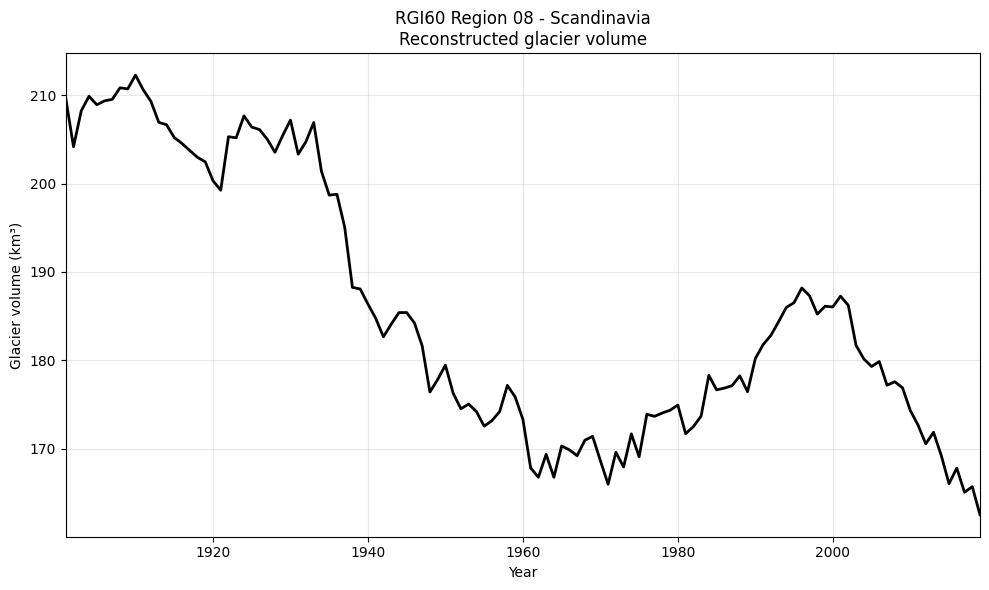

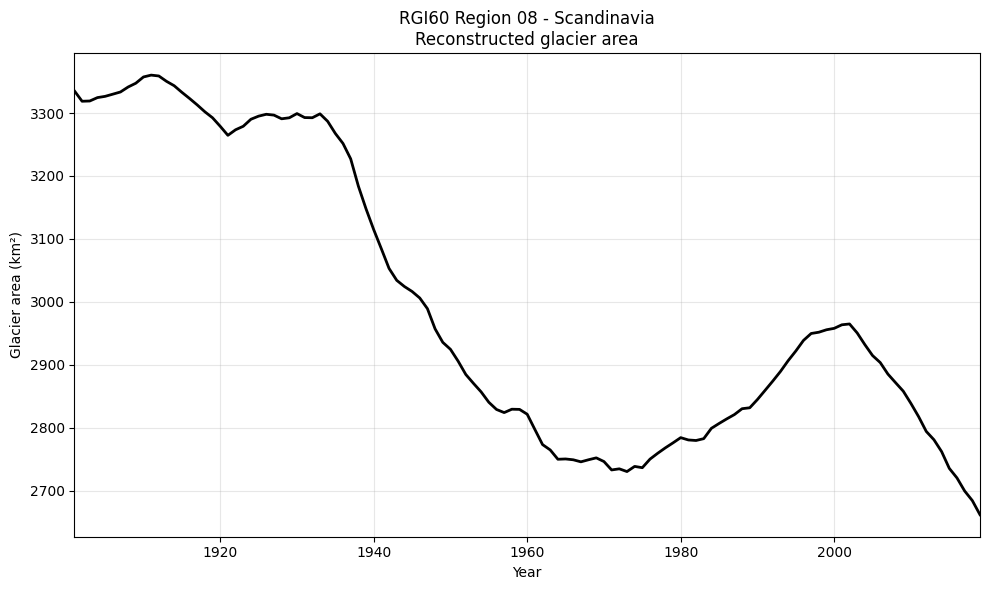

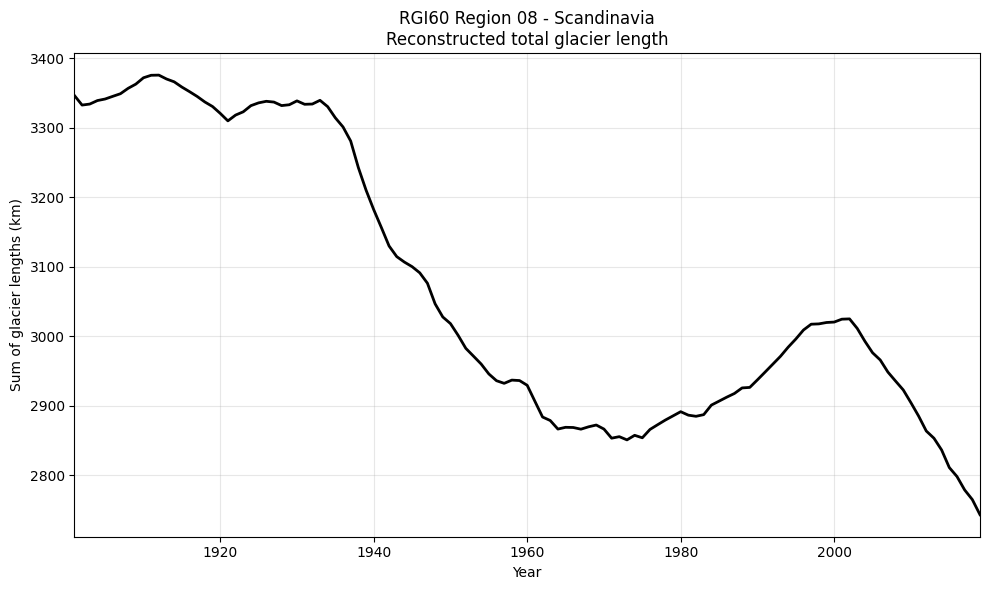

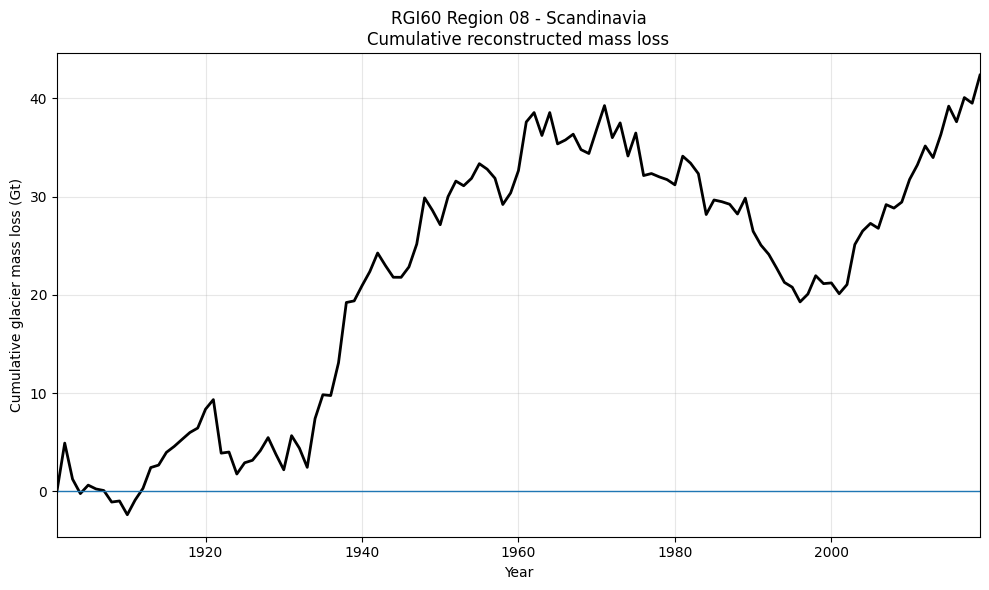

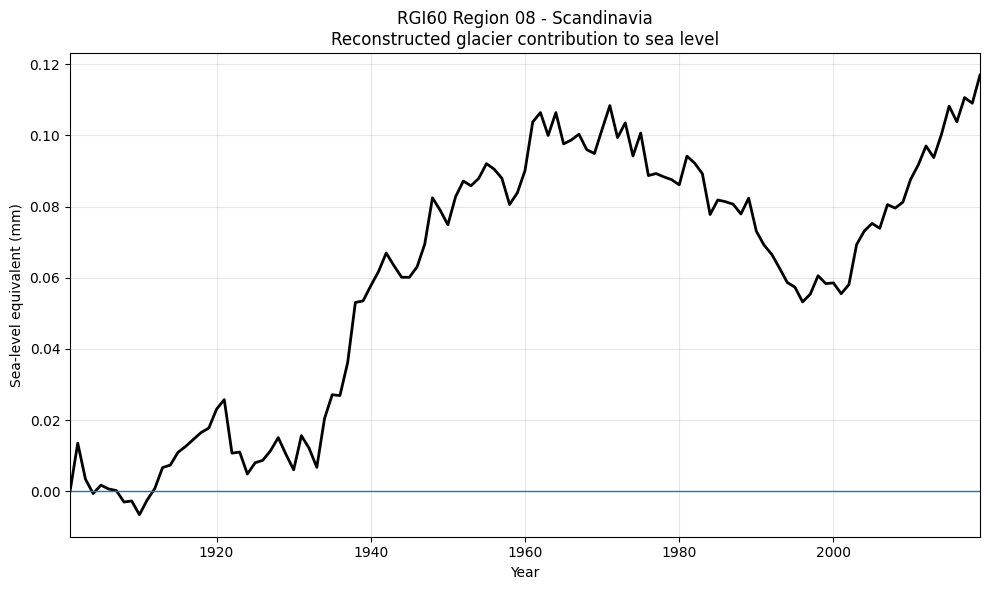

In [13]:
# ============================================================
# 13. PLOTS: HISTORICAL RECONSTRUCTION
# ============================================================
REGION_SLUG = REGION_NAME.replace(" ", "")

HIST_PLOTS = [
    # column, y label, title, file key, draw zero line
    ("volume_km3", "Glacier volume (km³)", "Reconstructed glacier volume", "volume", False),
    ("area_km2", "Glacier area (km²)", "Reconstructed glacier area", "area", False),
    ("length_km", "Sum of glacier lengths (km)", "Reconstructed total glacier length", "length", False),
    ("mass_loss_Gt", "Cumulative glacier mass loss (Gt)", "Cumulative reconstructed mass loss", "mass_loss", True),
    ("sea_level_change_mm", "Sea-level equivalent (mm)", "Reconstructed glacier contribution to sea level", "sle", True),
]

for column, ylabel, title, key, zero in HIST_PLOTS:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(regional_df["year"], regional_df[column], color=RECON_COLOR, linewidth=2)
    if zero:
        ax.axhline(0, linewidth=1)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(f"RGI60 Region {RGI_REGION:02d} - {REGION_NAME}\n{title}")
    ax.set_xlim(MODEL_START_YEAR, RECON_END_YEAR)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(WORKDIR / f"{REGION_SLUG}_{key}_{MODEL_START_YEAR}_{RECON_END_YEAR}.png", dpi=300)
    plt.show()
    plt.close(fig)


In [ ]:
# ============================================================
# 14. CMIP PROJECTIONS (one run per experiment)
# ============================================================
projections = {}          # experiment name -> regional DataFrame
projection_failures = {}  # experiment name -> reason


def run_projection(exp, gdirs):
    end_year = exp.end_year or FUTURE_END_YEAR
    regional_csv = WORKDIR / f"regional_results_future_{exp.name}.csv"
    glacier_csv = WORKDIR / f"glacier_results_future_{exp.name}.csv"

    # ---- reuse a finished projection ------------------------------------
    if REUSE_PROJECTIONS and regional_csv.exists():
        regional = pd.read_csv(regional_csv)
        years = set(regional["year"].astype(int))
        if FUTURE_START_YEAR in years and end_year in years:
            print("Existing projection found, reusing:", regional_csv.name)
            return add_mass_and_sle(regional, volume_start)

    # ---- 1. GCM forcing, bias-corrected against CRU ----------------------
    def has_forcing(g):
        return os.path.exists(g.get_filepath("gcm_data", filesuffix=exp.suffix))

    missing = list(gdirs) if OVERWRITE_CMIP else [g for g in gdirs if not has_forcing(g)]
    print(f"GCM forcing: {len(gdirs) - len(missing)} done already, {len(missing)} to process")

    forcing_errors = []
    if missing:
        forcing = CMIPForcing(exp, end_year=end_year)
        try:
            for i, gdir in enumerate(missing, start=1):
                try:
                    add_cmip_forcing(gdir, forcing)
                except Exception as exc:
                    forcing_errors.append((gdir.rgi_id, f"{type(exc).__name__}: {exc}"))
                if i % 250 == 0:
                    print(f"  forcing {i}/{len(missing)}")
        finally:
            forcing.close()

    if forcing_errors:
        print(f"GCM forcing failed for {len(forcing_errors)} glaciers:")
        summarize_errors(forcing_errors)
        pd.DataFrame(forcing_errors, columns=["rgi_id", "error"]).to_csv(
            WORKDIR / f"failed_cmip_{exp.name}.csv", index=False)

    scenario_gdirs = [g for g in gdirs if has_forcing(g)]
    if not scenario_gdirs:
        raise RuntimeError("no glacier has GCM forcing")

    # ---- 2. VAS projection from the reconstructed state -------------------
    print(f"VAS run {FUTURE_START_YEAR}-{end_year} for {len(scenario_gdirs)} glaciers")
    models = workflow.execute_entity_task(
        vascaling.run_from_climate_data,
        scenario_gdirs,
        ys=FUTURE_START_YEAR,
        ye=end_year,
        climate_filename="gcm_data",
        climate_input_filesuffix=exp.suffix,
        output_filesuffix=exp.future_suffix,
        init_model_filesuffix=HIST_SUFFIX,
        init_model_yr=FUTURE_START_YEAR,
    )
    ran = [g for g, m in zip(scenario_gdirs, models) if m is not None]

    future_glacier, read_errors = collect_results(ran, exp.future_suffix)
    if future_glacier.empty:
        raise RuntimeError("no successful future simulations")

    # ---- 3. glaciers lost between reconstruction and projection -----------
    start_vol = glacier_results.loc[glacier_results["year"] == FUTURE_START_YEAR]
    lost = ~start_vol["rgi_id"].isin(set(future_glacier["rgi_id"]))
    lost_fraction = float(start_vol.loc[lost, "volume_km3"].sum() / start_vol["volume_km3"].sum())
    pd.DataFrame({"rgi_id": start_vol.loc[lost, "rgi_id"]}).to_csv(
        WORKDIR / f"failed_future_{exp.name}.csv", index=False)
    if lost.any():
        print(f"WARNING: {int(lost.sum())} glaciers ({lost_fraction:.1%} of the "
              f"{FUTURE_START_YEAR} volume) are missing in this projection; "
              "the regional curve will drop at the transition year.")

    # ---- 4. regional aggregation, save ------------------------------------
    regional = aggregate_region(future_glacier)
    regional["lost_volume_fraction"] = lost_fraction
    regional = add_mass_and_sle(regional, volume_start)

    future_glacier.to_csv(glacier_csv, index=False)
    regional.to_csv(regional_csv, index=False)
    print("Saved:", regional_csv.name)
    return regional


if RUN_FUTURE and not EXPERIMENTS:
    print("RUN_FUTURE is True but EXPERIMENTS is empty: no projections.")

if RUN_FUTURE:
    for exp in EXPERIMENTS:
        print("\n" + "=" * 60)
        print(f"{exp.name}  ({exp.generation or 'CMIP'} {exp.scenario})")
        print("=" * 60)
        try:
            projections[exp.name] = run_projection(exp, gdirs)
        except Exception as exc:
            projection_failures[exp.name] = f"{type(exc).__name__}: {exc}"
            print(f"EXPERIMENT FAILED: {projection_failures[exp.name]}")

    print(f"\nFinished: {len(projections)} ok, {len(projection_failures)} failed")
    for name, reason in projection_failures.items():
        print(f"  {name}: {reason}")



CCSM4_rcp26  (CMIP5 rcp26)
GCM forcing: 0 done already, 3413 to process
  saved /home/JasperE/CMIP_data/downloads/14b79ab6_tas_mon_CCSM4_rcp26_r1i1p1_g025.nc (115.0 MB)


2026-10-07 10:26:29: oggm.shop.gcm_climate: (RGI60-08.00005) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00006) process_gcm_data_CCSM4_rcp26


  saved /home/JasperE/CMIP_data/downloads/f30760f8_pr_mon_CCSM4_rcp26_r1i1p1_g025.nc (115.0 MB)


2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00007) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00008) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00009) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00010) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00011) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00012) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00013) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00014) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:30: oggm.shop.gcm_climate: (RGI60-08.00015) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:31: oggm.shop.gcm_climate: (RGI60-08.00016) process_gcm_data_CCSM4_rcp26
2026-10-07 10:26:31: oggm.shop.gcm_climate: (RGI60-08.00017) process_gcm_data_CCSM4_rcp26
2026-10-07

  forcing 250/3413


...

  forcing 3000/3413


2026-10-07 10:48:22: oggm.shop.gcm_climate: (RGI60-08.03008) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:22: oggm.shop.gcm_climate: (RGI60-08.03009) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:22: oggm.shop.gcm_climate: (RGI60-08.03010) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:22: oggm.shop.gcm_climate: (RGI60-08.03011) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:22: oggm.shop.gcm_climate: (RGI60-08.03012) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:23: oggm.shop.gcm_climate: (RGI60-08.03013) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:23: oggm.shop.gcm_climate: (RGI60-08.03014) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:23: oggm.shop.gcm_climate: (RGI60-08.03015) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:23: oggm.shop.gcm_climate: (RGI60-08.03016) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:23: oggm.shop.gcm_climate: (RGI60-08.03017) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:23: oggm.shop.gcm_climate: (RGI60-08.03018) process_gcm_data_CCSM4_rcp85
2026-10-07

  forcing 3250/3413


2026-10-07 10:48:45: oggm.shop.gcm_climate: (RGI60-08.03258) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:45: oggm.shop.gcm_climate: (RGI60-08.03259) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:45: oggm.shop.gcm_climate: (RGI60-08.03260) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:46: oggm.shop.gcm_climate: (RGI60-08.03261) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:46: oggm.shop.gcm_climate: (RGI60-08.03262) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:46: oggm.shop.gcm_climate: (RGI60-08.03263) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:46: oggm.shop.gcm_climate: (RGI60-08.03264) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:46: oggm.shop.gcm_climate: (RGI60-08.03265) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:46: oggm.shop.gcm_climate: (RGI60-08.03266) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:46: oggm.shop.gcm_climate: (RGI60-08.03267) process_gcm_data_CCSM4_rcp85
2026-10-07 10:48:46: oggm.shop.gcm_climate: (RGI60-08.03268) process_gcm_data_CCSM4_rcp85
2026-10-07

VAS run 2019-2100 for 3413 glaciers


In [15]:
# ============================================================
# 15. REGIONAL CRU OBSERVATION SERIES (area-weighted)
# ============================================================
#
# CRU does not observe glaciers; this is the CRU climate of the glacier grid
# cells (as stored in climate_historical), weighted by RGI glacier area.

ref_start, ref_end = int(BIAS_CORRECTION_PERIOD[0]), int(BIAS_CORRECTION_PERIOD[1])
area_lookup = rgidf.set_index("rgi_id")["Area"].to_dict()

frames = []
for gdir in gdirs:
    climate_file = gdir.get_filepath("climate_historical")
    if not os.path.exists(climate_file):
        continue
    try:
        with xr.open_dataset(climate_file) as ds:
            df = pd.DataFrame({"year": ds["time"].dt.year.values,
                               "temp": ds["temp"].values,
                               "prcp": ds["prcp"].values})
    except Exception as exc:
        print(f"Could not read CRU for {gdir.rgi_id}: {exc}")
        continue
    annual = df.groupby("year").agg(temp=("temp", "mean"), prcp=("prcp", "sum")).reset_index()
    annual["w"] = area_lookup.get(gdir.rgi_id, np.nan)
    frames.append(annual)

cru_all = pd.concat(frames, ignore_index=True)


def weighted_mean_by_year(df, column):
    d = df[np.isfinite(df[column]) & np.isfinite(df["w"]) & (df["w"] > 0)]
    return (d[column] * d["w"]).groupby(d["year"]).sum() / d["w"].groupby(d["year"]).sum()


cru_regional = pd.DataFrame({
    "cru_temperature_C": weighted_mean_by_year(cru_all, "temp"),
    "cru_precipitation_mm": weighted_mean_by_year(cru_all, "prcp"),
}).reset_index()

ref = cru_regional[cru_regional["year"].between(ref_start, ref_end)]
cru_regional["cru_temperature_anomaly_C"] = (
    cru_regional["cru_temperature_C"] - ref["cru_temperature_C"].mean())
cru_regional["cru_precipitation_anomaly_percent"] = (
    cru_regional["cru_precipitation_mm"] / ref["cru_precipitation_mm"].mean() - 1) * 100

cru_regional.to_csv(WORKDIR / f"regional_cru_observations_{MODEL_START_YEAR}_{RECON_END_YEAR}.csv", index=False)
print("CRU observation series saved.")


CRU observation series saved.


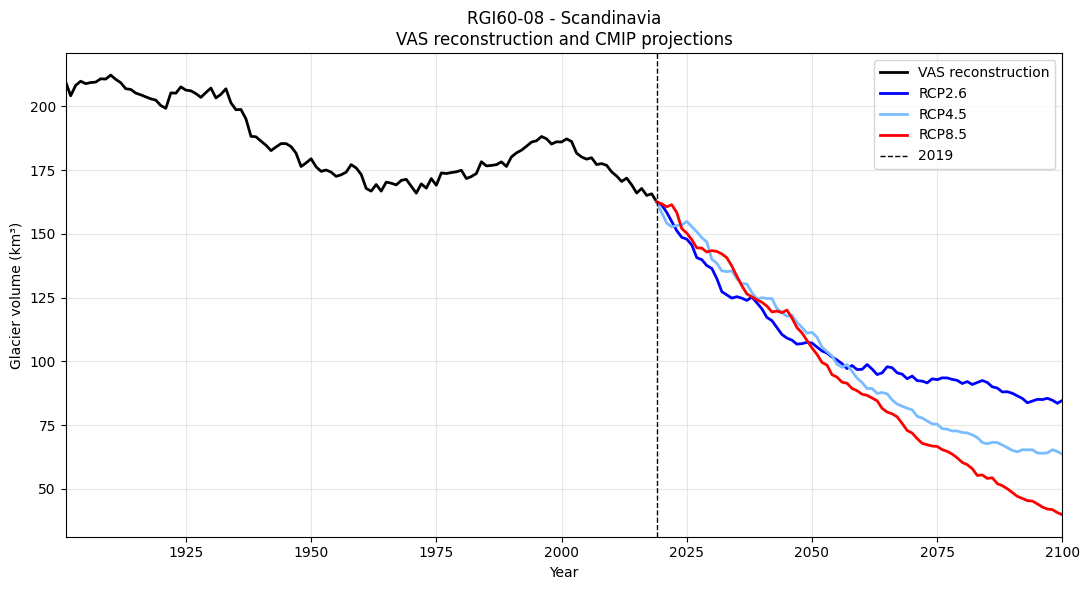

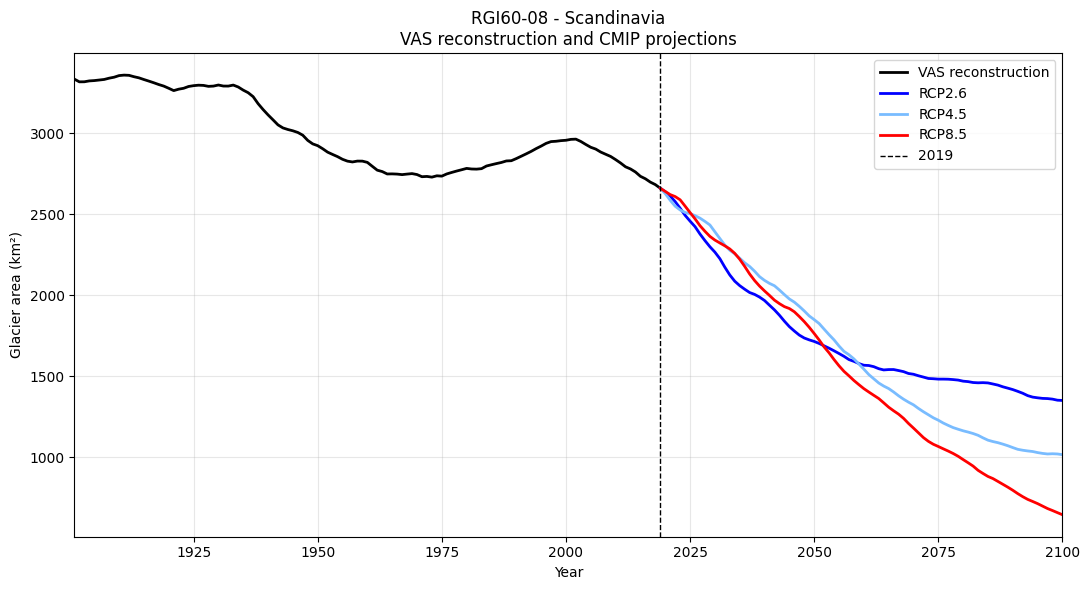

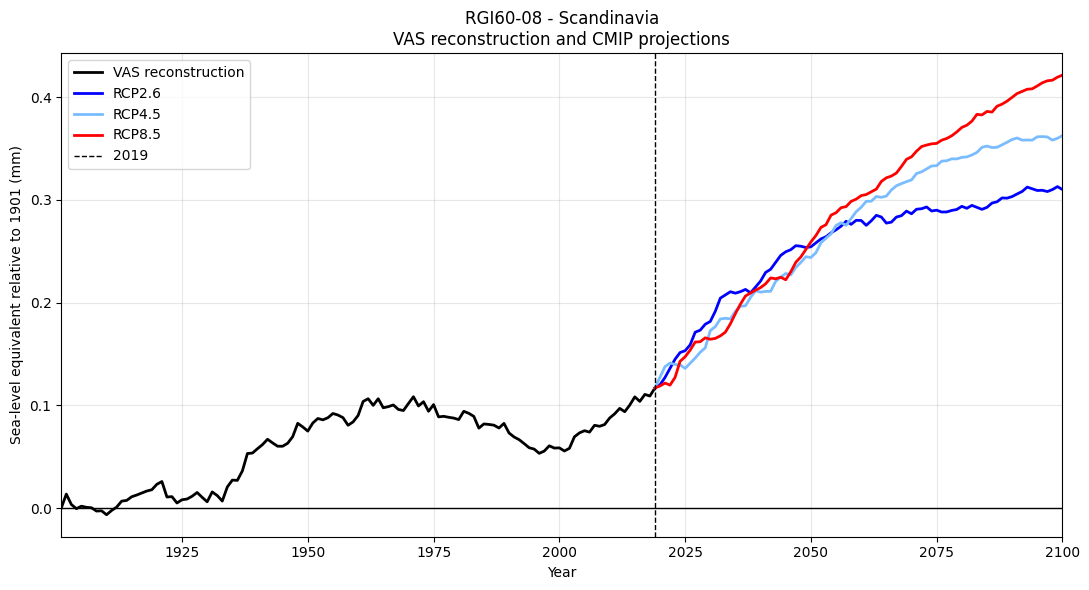

In [16]:
# ============================================================
# 16. COMBINED PLOTS (reconstruction + all projections)
# ============================================================
COMBINED_PLOTS = [
    ("volume_km3", "Glacier volume (km³)", "volume", False),
    ("area_km2", "Glacier area (km²)", "area", False),
    ("sea_level_change_mm", f"Sea-level equivalent relative to {MODEL_START_YEAR} (mm)", "sea_level", True),
]

if RUN_FUTURE and projections:
    x_max = max(df["year"].max() for df in projections.values())

    for column, ylabel, key, zero in COMBINED_PLOTS:
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.plot(regional_df["year"], regional_df[column],
                color=RECON_COLOR, linewidth=2, label="VAS reconstruction")
        for exp in EXPERIMENTS:
            if exp.name in projections:
                df = projections[exp.name]
                ax.plot(df["year"], df[column], color=experiment_color(exp),
                        linestyle=experiment_linestyle(exp),
                        linewidth=2, label=experiment_label(exp))
        ax.axvline(RECON_END_YEAR, color="black", linestyle="--", linewidth=1, label=str(RECON_END_YEAR))
        if zero:
            ax.axhline(0, color="black", linewidth=1)
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)
        ax.set_title(f"RGI60-{RGI_REGION:02d} - {REGION_NAME}\nVAS reconstruction and CMIP projections")
        ax.set_xlim(MODEL_START_YEAR, x_max)
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(WORKDIR / f"{key}_{MODEL_START_YEAR}_{int(x_max)}_all_experiments.png", dpi=300)
        plt.show()
        plt.close(fig)


In [17]:
# ============================================================
# 17. PROJECTION SUMMARY
# ============================================================
rows = []
for exp in EXPERIMENTS:
    df = projections.get(exp.name)
    if df is None:
        continue
    first = df.loc[df["year"] == FUTURE_START_YEAR].iloc[0]
    last = df.iloc[-1]
    rows.append({
        "experiment": exp.name,
        "generation": exp.generation,
        "scenario": exp.scenario,
        "scenario_label": experiment_label(exp),
        "start_year": FUTURE_START_YEAR,
        "end_year": int(last["year"]),
        "volume_start_km3": first["volume_km3"],
        "volume_end_km3": last["volume_km3"],
        "area_start_km2": first["area_km2"],
        "area_end_km2": last["area_km2"],
        "sea_level_end_mm": last["sea_level_change_mm"],
        "lost_volume_fraction": df["lost_volume_fraction"].iloc[0]
        if "lost_volume_fraction" in df else np.nan,
    })

projection_summary = pd.DataFrame(rows)
if not projection_summary.empty:
    projection_summary.to_csv(WORKDIR / "projection_summary.csv", index=False)
    print("\nProjection summary:")
    print(projection_summary.to_string(index=False))



Projection summary:
 experiment generation scenario scenario_label  start_year  end_year  volume_start_km3  volume_end_km3  area_start_km2  area_end_km2  sea_level_end_mm  lost_volume_fraction
CCSM4_rcp26      CMIP5    rcp26         RCP2.6        2019      2100        162.539586       84.742550     2661.709072   1351.359812          0.310054                   0.0
CCSM4_rcp45      CMIP5    rcp45         RCP4.5        2019      2100        162.539586       63.617496     2661.709072   1016.530102          0.362502                   0.0
CCSM4_rcp85      CMIP5    rcp85         RCP8.5        2019      2100        162.539586       39.889739     2661.709072    645.655372          0.421413                   0.0
